In [49]:
# =====================================================
# Model Training - Rider-Level Customer Churn
# =====================================================

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

In [50]:
# =====================================================
# Load Rider-Level Feature Dataset
# =====================================================

df = pd.read_csv("../data/processed/rider_level_churn_dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())

assert "is_churned" in df.columns, "Target column is missing."
assert df["user_id"].is_unique, "Duplicate user_id values found."

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (10000, 48)


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,referred_by,is_referred,total_trips,avg_fare,...,tip_ratio,spend_per_day,session_intensity,app_usage_score,conversion_engagement_score,non_standard_trip_rate,surge_fare_interaction,loyalty_spend_interaction,age_group,is_churned
0,R00000,2025-01-24 00:00:00+00:00,Bronze,34.729629,Nairobi,5.0,R00001,1,25,14.642000,...,0.011009,3.936022,0.043011,276.000000,9.75,0.520000,16.047632,98.400538,26-35,0
1,R00001,2024-09-09 00:00:00+00:00,Bronze,34.571020,Nairobi,4.7,Unknown,0,14,12.895000,...,0.004210,0.784913,0.013043,465.777778,0.00,0.571429,13.816071,10.988783,26-35,0
2,R00002,2024-09-07 00:00:00+00:00,Bronze,47.133960,Lagos,4.2,Unknown,0,24,15.791250,...,0.013747,1.633578,0.012931,573.000000,0.00,0.291667,18.817906,39.205862,46-60,0
3,R00003,2025-03-17 00:00:00+00:00,Bronze,41.658628,Nairobi,4.9,Unknown,0,9,13.496667,...,0.007162,2.962683,0.073171,125.555556,0.00,1.000000,15.596148,26.664146,36-45,1
4,R00004,2024-08-20 00:00:00+00:00,Silver,40.681709,Lagos,3.9,R00002,1,16,16.776875,...,0.034944,1.073720,0.008000,42.500000,0.00,0.687500,21.180805,17.179520,36-45,0



Columns:
['user_id', 'signup_date', 'loyalty_status', 'age', 'city', 'avg_rating_given', 'referred_by', 'is_referred', 'total_trips', 'avg_fare', 'total_fare', 'avg_surge', 'avg_tip', 'avg_tip_percentage', 'avg_trip_duration', 'avg_fare_per_minute', 'avg_driver_rating', 'avg_driver_acceptance', 'driver_info_missing_rate', 'weekend_trip_rate', 'peak_hour_trip_rate', 'night_trip_rate', 'surge_trip_rate', 'favourite_payment_type', 'favourite_weather', 'favourite_vehicle_type', 'total_sessions', 'avg_time_on_app', 'avg_pages_visited', 'conversion_rate', 'account_tenure_days', 'trip_velocity', 'trips_per_session', 'engagement_score', 'avg_days_between_trips', 'fare_per_session', 'trips_per_active_day', 'driver_quality_score', 'tip_ratio', 'spend_per_day', 'session_intensity', 'app_usage_score', 'conversion_engagement_score', 'non_standard_trip_rate', 'surge_fare_interaction', 'loyalty_spend_interaction', 'age_group', 'is_churned']


In [51]:
# =====================================================
# Define Target and Features
# =====================================================

target = "is_churned"

drop_cols = [
    "is_churned",
    "user_id",
    "signup_date",
    "referred_by"
]

y = df[target]
X = df.drop(columns=drop_cols, errors="ignore")

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget percentage:")
print(y.value_counts(normalize=True).mul(100).round(2))

assert all(col not in X.columns for col in drop_cols), "Some drop columns are still in X."
print("\nValidation passed: unwanted columns removed.")

Feature shape: (10000, 44)
Target shape: (10000,)

Target distribution:
is_churned
0    8114
1    1886
Name: count, dtype: int64

Target percentage:
is_churned
0    81.14
1    18.86
Name: proportion, dtype: float64

Validation passed: unwanted columns removed.


In [52]:
# =====================================================
# Identify Numerical and Categorical Features
# =====================================================

categorical_features = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['loyalty_status', 'city', 'favourite_payment_type', 'favourite_weather', 'favourite_vehicle_type', 'age_group']

Numerical features:
['age', 'avg_rating_given', 'is_referred', 'total_trips', 'avg_fare', 'total_fare', 'avg_surge', 'avg_tip', 'avg_tip_percentage', 'avg_trip_duration', 'avg_fare_per_minute', 'avg_driver_rating', 'avg_driver_acceptance', 'driver_info_missing_rate', 'weekend_trip_rate', 'peak_hour_trip_rate', 'night_trip_rate', 'surge_trip_rate', 'total_sessions', 'avg_time_on_app', 'avg_pages_visited', 'conversion_rate', 'account_tenure_days', 'trip_velocity', 'trips_per_session', 'engagement_score', 'avg_days_between_trips', 'fare_per_session', 'trips_per_active_day', 'driver_quality_score', 'tip_ratio', 'spend_per_day', 'session_intensity', 'app_usage_score', 'conversion_engagement_score', 'non_standard_trip_rate', 'surge_fare_interaction', 'loyalty_spend_interaction']


In [54]:
# =====================================================
# Train-Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train: (8000, 44)
X_test: (2000, 44)

Train target distribution:
is_churned
0    81.14
1    18.86
Name: proportion, dtype: float64

Test target distribution:
is_churned
0    81.15
1    18.85
Name: proportion, dtype: float64


In [55]:
# =====================================================
# Preprocessing Pipeline
# =====================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [56]:
# =====================================================
# Evaluation Function
# =====================================================

def evaluate_model(model_name, model, X_test, y_test, threshold=0.50):
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = roc_auc_score(y_test, probs)

    print("=" * 60)
    print(f"{model_name} | Threshold: {threshold:.2f}")
    print("=" * 60)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, preds))

    print("\nClassification Report:")
    print(classification_report(y_test, preds, zero_division=0))

    print("\nPerformance Metrics")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [57]:
# =====================================================
# Build Models
# =====================================================

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=10,
                min_samples_leaf=5,
                min_samples_split=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=500,
                max_depth=3,
                learning_rate=0.03,
                subsample=0.9,
                colsample_bytree=0.9,
                min_child_weight=5,
                gamma=1,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

In [58]:
# =====================================================
# Cross-Validation
# =====================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

print("Cross-Validation ROC-AUC Results:")
display(cv_results_df.sort_values(by="Mean ROC-AUC", ascending=False))

Cross-Validation ROC-AUC Results:


,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.609100,0.011572
1,Random Forest,0.605447,0.006002
2,XGBoost,0.585432,0.013363


In [59]:
# =====================================================
# Train and Evaluate Models at Default Threshold
# =====================================================

model_results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    result = evaluate_model(
        name,
        model,
        X_test,
        y_test,
        threshold=0.50
    )

    model_results.append(result)

model_results_df = pd.DataFrame(model_results)

print("Model Comparison at Threshold 0.50:")
display(model_results_df.sort_values(by="ROC-AUC", ascending=False))

Logistic Regression | Threshold: 0.50

Confusion Matrix:
[[930 693]
 [151 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.57      0.69      1623
           1       0.25      0.60      0.35       377

    accuracy                           0.58      2000
   macro avg       0.55      0.59      0.52      2000
weighted avg       0.74      0.58      0.62      2000


Performance Metrics
----------------------------------------
Accuracy : 0.5780
Precision: 0.2459
Recall   : 0.5995
F1-Score : 0.3488
ROC-AUC  : 0.6200
Random Forest | Threshold: 0.50

Confusion Matrix:
[[1343  280]
 [ 265  112]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1623
           1       0.29      0.30      0.29       377

    accuracy                           0.73      2000
   macro avg       0.56      0.56      0.56      2000
weighted avg       0.73      0.73      0.73

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5,0.5780,0.245919,0.599469,0.348765,0.620042
1,Random Forest,0.5,0.7275,0.285714,0.297082,0.291287,0.615492
2,XGBoost,0.5,0.6175,0.244737,0.493369,0.327177,0.608550


In [60]:
# =====================================================
# Threshold Tuning
# =====================================================

thresholds = np.arange(0.20, 0.61, 0.05)

threshold_results = []

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)

        threshold_results.append({
            "Model": name,
            "Threshold": round(threshold, 2),
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1 Score": f1_score(y_test, preds, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, probs)
        })

threshold_results_df = pd.DataFrame(threshold_results)

print("Threshold Tuning Results:")
display(
    threshold_results_df
    .sort_values(by="F1 Score", ascending=False)
    .head(15)
)

Threshold Tuning Results:


,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
23,XGBoost,0.45,0.5490,0.246377,0.676393,0.361190,0.608550
13,Random Forest,0.40,0.5270,0.238270,0.687003,0.353825,0.615492
6,Logistic Regression,0.50,0.5780,0.245919,0.599469,0.348765,0.620042
5,Logistic Regression,0.45,0.4745,0.226016,0.737401,0.345986,0.620042
4,Logistic Regression,0.40,0.3895,0.215250,0.846154,0.343195,0.620042
22,XGBoost,0.40,0.4380,0.217260,0.761273,0.338045,0.608550
11,Random Forest,0.30,0.3345,0.207721,0.899204,0.337481,0.615492
21,XGBoost,0.35,0.3595,0.209512,0.864721,0.337300,0.608550
3,Logistic Regression,0.35,0.3135,0.206021,0.925729,0.337035,0.620042
12,Random Forest,0.35,0.4025,0.212377,0.801061,0.335742,0.615492


In [61]:
# =====================================================
# Threshold Tuning
# =====================================================

thresholds = np.arange(0.20, 0.61, 0.05)

threshold_results = []

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)

        threshold_results.append({
            "Model": name,
            "Threshold": round(threshold, 2),
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1 Score": f1_score(y_test, preds, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, probs)
        })

threshold_results_df = pd.DataFrame(threshold_results)

print("Threshold Tuning Results:")
display(
    threshold_results_df
    .sort_values(by="F1 Score", ascending=False)
    .head(15)
)

Threshold Tuning Results:


,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
23,XGBoost,0.45,0.5490,0.246377,0.676393,0.361190,0.608550
13,Random Forest,0.40,0.5270,0.238270,0.687003,0.353825,0.615492
6,Logistic Regression,0.50,0.5780,0.245919,0.599469,0.348765,0.620042
5,Logistic Regression,0.45,0.4745,0.226016,0.737401,0.345986,0.620042
4,Logistic Regression,0.40,0.3895,0.215250,0.846154,0.343195,0.620042
22,XGBoost,0.40,0.4380,0.217260,0.761273,0.338045,0.608550
11,Random Forest,0.30,0.3345,0.207721,0.899204,0.337481,0.615492
21,XGBoost,0.35,0.3595,0.209512,0.864721,0.337300,0.608550
3,Logistic Regression,0.35,0.3135,0.206021,0.925729,0.337035,0.620042
12,Random Forest,0.35,0.4025,0.212377,0.801061,0.335742,0.615492


In [62]:
# =====================================================
# Select Best Model Based on F1 Score
# =====================================================

best_row = (
    threshold_results_df
    .sort_values(by="F1 Score", ascending=False)
    .iloc[0]
)

best_model_name = best_row["Model"]
best_threshold = best_row["Threshold"]
best_model = models[best_model_name]

print("Best Model Selection")
print("-" * 40)
print("Best model:", best_model_name)
print("Best threshold:", best_threshold)

best_results = evaluate_model(
    best_model_name,
    best_model,
    X_test,
    y_test,
    threshold=best_threshold
)

Best Model Selection
----------------------------------------
Best model: XGBoost
Best threshold: 0.45
XGBoost | Threshold: 0.45

Confusion Matrix:
[[843 780]
 [122 255]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.52      0.65      1623
           1       0.25      0.68      0.36       377

    accuracy                           0.55      2000
   macro avg       0.56      0.60      0.51      2000
weighted avg       0.76      0.55      0.60      2000


Performance Metrics
----------------------------------------
Accuracy : 0.5490
Precision: 0.2464
Recall   : 0.6764
F1-Score : 0.3612
ROC-AUC  : 0.6085


In [63]:
# =====================================================
# Model Comparison Summary
# =====================================================

summary_df = (
    threshold_results_df
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

display(summary_df.head(10))

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.45,0.5490,0.246377,0.676393,0.361190,0.608550
1,Random Forest,0.40,0.5270,0.238270,0.687003,0.353825,0.615492
2,Logistic Regression,0.50,0.5780,0.245919,0.599469,0.348765,0.620042
3,Logistic Regression,0.45,0.4745,0.226016,0.737401,0.345986,0.620042
4,Logistic Regression,0.40,0.3895,0.215250,0.846154,0.343195,0.620042
5,XGBoost,0.40,0.4380,0.217260,0.761273,0.338045,0.608550
6,Random Forest,0.30,0.3345,0.207721,0.899204,0.337481,0.615492
7,XGBoost,0.35,0.3595,0.209512,0.864721,0.337300,0.608550
8,Logistic Regression,0.35,0.3135,0.206021,0.925729,0.337035,0.620042
9,Random Forest,0.35,0.4025,0.212377,0.801061,0.335742,0.615492


Top 20 Feature Importances:


,Feature,Importance
3,num__total_trips,0.055949
28,num__trips_per_active_day,0.052683
58,cat__age_group_46-60,0.027330
41,cat__loyalty_status_Silver,0.023417
55,cat__age_group_18-25,0.021335
8,num__avg_tip_percentage,0.019741
52,cat__favourite_vehicle_type_Motorcycle,0.019677
11,num__avg_driver_rating,0.019107
5,num__total_fare,0.018917
56,cat__age_group_26-35,0.018782


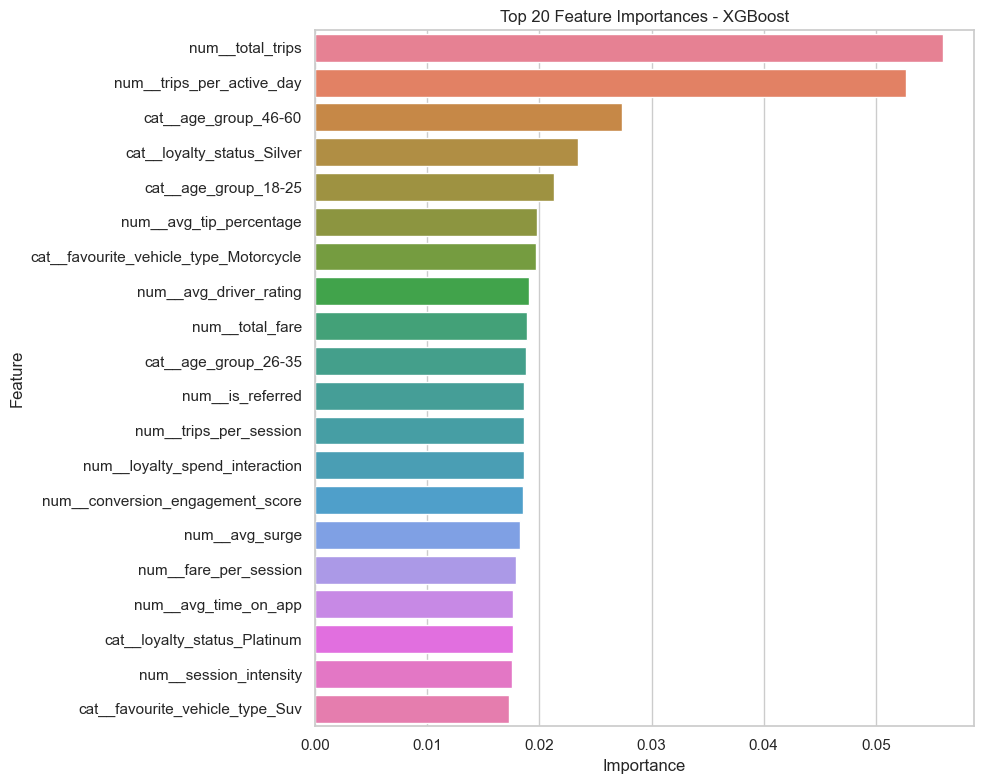

In [64]:
# =====================================================
# Feature Importance for Tree-Based Best Model
# =====================================================

if best_model_name in ["XGBoost", "Random Forest"]:

    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    importances = best_model.named_steps["classifier"].feature_importances_

    feature_importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        })
        .sort_values(by="Importance", ascending=False)
    )

    print("Top 20 Feature Importances:")
    display(feature_importance_df.head(20))

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=feature_importance_df.head(20),
        x="Importance",
        y="Feature",
        hue="Feature",
        legend=False
    )

    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

In [65]:
# =====================================================
# Save Models and Threshold
# =====================================================

joblib.dump(
    log_reg_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

joblib.dump(
    xgb_model,
    "../models/xgboost.pkl"
)

joblib.dump(
    best_model,
    "../models/churn_prediction_model.pkl"
)

joblib.dump(
    best_threshold,
    "../models/churn_prediction_threshold.pkl"
)

print("Models saved successfully.")
print("Best model:", best_model_name)
print("Best threshold:", best_threshold)

Models saved successfully.
Best model: XGBoost
Best threshold: 0.45
